# Geometry visualization

We have already been extensively using the `plot()` method on various geometric classes, including `Model`, `Geometry`, `Universe`, `Cell`, and `Region`. We can also visualize geometry in other ways, which can offer more control over plotting (e.g., if we want to produce a series of plots or view the geometry in a format other than a slice).

## The `Plot` class

The `Plot` class allows us to pass information to OpenMC on a slice plot that we want to view. Most of the attributes on this class are the same as what appears on the `Model.plot` method. Let's see how we can manually create a plot using this class. First, we will create a simple model with two half-spherical shells.

In [1]:
import openmc
from IPython.display import Image
import matplotlib.image as mpimg
from matplotlib import pyplot as plt

In [2]:
mat = openmc.Material()
mat.add_nuclide('U235', 1.0)
mat.set_density('g/cm3', 1.0)

p = openmc.XPlane()
sph1 = openmc.Sphere(r=5.0)
sph2 = openmc.Sphere(r=10.0)
sph3 = openmc.Sphere(r=13.0)
sph4 = openmc.Sphere(r=15.0)
sph5 = openmc.Sphere(r=50.0)

cell1 = openmc.Cell(fill=mat, region=+sph1 & -sph2 & -p)
cell2 = openmc.Cell(fill=mat, region=+sph3 & -sph4 & -p)
empty = openmc.Cell(region=-sph5 & ~cell1.region & ~cell2.region)

model = openmc.Model()
model.geometry = openmc.Geometry([cell1, cell2, empty])
model.settings.particles = 1000
model.settings.batches = 10
model.settings.inactive = 5

Now create a `Plot` instance and assign attributes for the slice view that we want.

In [3]:
plot = openmc.Plot()
plot.width = (35., 35.)
plot.origin = (0., 0., 0.)
plot.pixels = (400, 400)
plot.color_by = 'cell'
plot.filename = 'xy_slice.png'

/Users/anovak/miniforge/envs/moose/lib/python3.14/site-packages/openmc/plots.py:1387: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(


To use this in OpenMC, we need to add it onto the `plots` attribute of `Model`:

In [4]:
model.plots = [plot]

And now run OpenMC in plotting mode to produce a plot. From a command-line, this can be done by executing `openmc --plot`. From the Python API, we call the `Model.plot_geometry` method. Like the `run` method, it takes care of exporting a model to XML.

In [5]:
model.plot_geometry()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

To display the image, we can open it from the file explorer, or we can use the `Image` class from `IPython.display`.

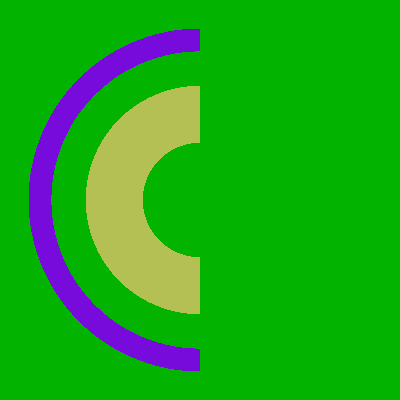

In [6]:
Image('xy_slice.png')

Internally, OpenMC uses `matplotlib.image.imread` to load the data and plot it.

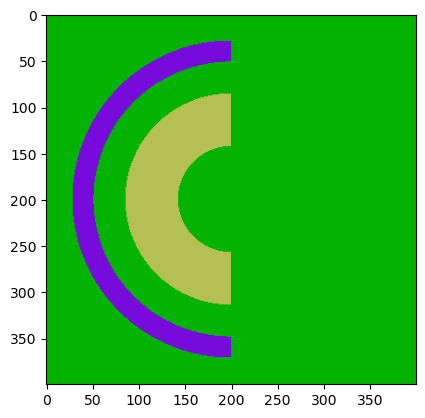

In [7]:
img = mpimg.imread('xy_slice.png')
plt.imshow(img)

Comparing this to what we get from `Model.plot`, we can also see that one of the nice things that the `Model.plot` method does for us is labeling the axes properly without any extra work.

## 3D plots: Raytrace plots

There are also two plot classes that allow us to produce raytraced 3D plots directly using OpenMC's geometry engine: `WireframeRayTracePlot` and `SolidRayTracePlot`. These plots operate similar to the other classes in that you create an instance of them, attach it to the `plots` attribute of a `Model`, and then run in geometry plotting mode. Like slice plots, they will produce .png files that can be viewed.

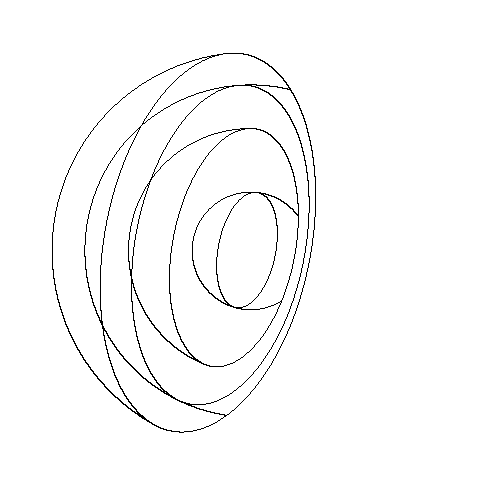

In [8]:
plot = openmc.WireframeRayTracePlot()
plot.look_at = (0., 0., 0.)
plot.camera_position = (15., -25., 10.)
plot.pixels = (500, 500)
plot.filename = 'wireframe_plot'
plot.wireframe_domains = [cell1, cell2]
plot.mask_components = [empty]

model.plots = [plot]
model.plot_geometry(output=False)
Image('wireframe_plot.png')

The `SolidRayTracePlot` tends to produce better looking 3D visualizations but may take some playing around with to get the right angle/field of vision.

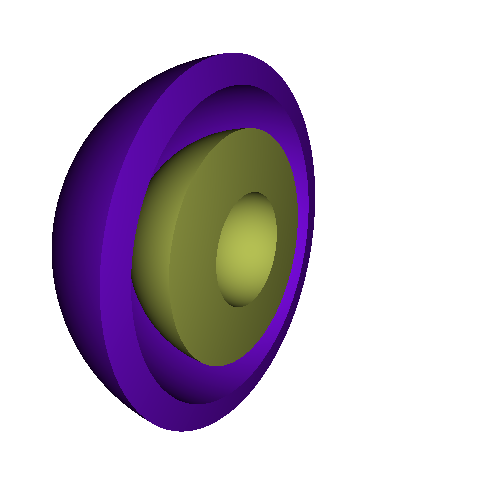

In [9]:
plot = openmc.SolidRayTracePlot()
plot.look_at = (0., 0., 0.)
plot.camera_position = (15., -25., 10.)
plot.pixels = (500, 500)
plot.filename = 'solid_plot'
plot.color_by = 'cell'
plot.opaque_domains = [cell1, cell2]

model.plots = [plot]
model.plot_geometry(output=False)
Image('solid_plot.png')

## `openmc-plotter`

The `openmc-plotter` is a Python package which provides an interactive GUI for viewing and inspecting OpenMC models. This Python package is pip-installable with

```
pip install openmc-plotter
```

To run the plotter, you will simply call `openmc-plotter` in a location where you have the XML files corresponding to an OpenMC model. 